In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
import torch
import torch.nn as nn
from torch.optim import Optimizer
import matplotlib.pyplot as plt



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

In [4]:
train, test = random_split(dataset, lengths=[0.8, 0.2])

train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test, shuffle=True, num_workers=4)

In [5]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [6]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.max_pool(x)
        x = self.relu(self.conv2(x))
        x = self.max_pool(x)
        x = self.flatten(x)
        x = self.fc1(x)
        return x
    

model = CNN()
model = model.to(device)
model.forward(images.to(device)).shape
        

torch.Size([64, 10])

In [7]:
def train(model: CNN, train_loader: DataLoader, val_loader: DataLoader, epochs: int, optimiser: Optimizer, criterion) -> tuple[list[float], list[float], list[float]]:
    accuracy_values: list[float] = []
    eval_loss: list[float] = []
    train_loss: list[float] = []
    for epoch in range(epochs):
        running_train_loss = 0.0
        running_train_total = 0
        for batch_data, batch_labels in train_loader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            optimiser.zero_grad()
            outputs = model(batch_data)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimiser.step()
            
            running_train_loss += loss.item() * batch_data.size(0)
            running_train_total += batch_data.size(0)
        model.eval()
        
        
        total_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch_data, batch_labels in val_loader:
                batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

                outputs = model(batch_data)
                loss = criterion(outputs, batch_labels)
                total_loss += loss.item() * batch_data.size(0)
                
                preds = outputs.argmax(dim=1)
                correct += (preds == batch_labels).sum().item()
                total += batch_labels.size(0)
                
        average_train_loss = running_train_loss / running_train_total
        average_eval_loss = total_loss / total
        accuracy = correct / total
        
        train_loss.append(average_train_loss)
        eval_loss.append(average_eval_loss)
        accuracy_values.append(accuracy)
        print(f"Epoch: {epoch} eval loss: {average_eval_loss:.4f}, train loss: {average_train_loss:.4f}, accuracy: {accuracy:.4f}")
        model.train()
        
    return accuracy_values, eval_loss, train_loss

In [8]:
optimiser = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()
sgd_accuracy, sgd_eval_loss, sgd_train_loss = train(
    model=model, 
    train_loader=train_loader, 
    val_loader=test_loader, 
    epochs=25, 
    optimiser=optimiser, 
    criterion=criterion
)

Epoch: 0 eval loss: 0.3035, train loss: 0.7455, accuracy: 0.9117
Epoch: 1 eval loss: 0.1964, train loss: 0.2352, accuracy: 0.9429
Epoch: 2 eval loss: 0.1568, train loss: 0.1671, accuracy: 0.9534
Epoch: 3 eval loss: 0.1350, train loss: 0.1317, accuracy: 0.9607
Epoch: 4 eval loss: 0.1082, train loss: 0.1100, accuracy: 0.9699
Epoch: 5 eval loss: 0.0960, train loss: 0.0966, accuracy: 0.9723
Epoch: 6 eval loss: 0.0883, train loss: 0.0869, accuracy: 0.9744
Epoch: 7 eval loss: 0.0846, train loss: 0.0802, accuracy: 0.9752
Epoch: 8 eval loss: 0.0830, train loss: 0.0742, accuracy: 0.9750
Epoch: 9 eval loss: 0.0755, train loss: 0.0696, accuracy: 0.9764
Epoch: 10 eval loss: 0.0726, train loss: 0.0656, accuracy: 0.9778
Epoch: 11 eval loss: 0.0684, train loss: 0.0623, accuracy: 0.9804
Epoch: 12 eval loss: 0.0672, train loss: 0.0593, accuracy: 0.9794
Epoch: 13 eval loss: 0.0708, train loss: 0.0567, accuracy: 0.9785
Epoch: 14 eval loss: 0.0676, train loss: 0.0549, accuracy: 0.9797
Epoch: 15 eval loss:

In [9]:
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
adam_accuarcy, adam_eval_loss, adam_train_loss = train(
    model=model, 
    train_loader=train_loader, 
    val_loader=test_loader, 
    epochs=25, 
    optimiser=optimiser, 
    criterion=criterion
)

Epoch: 0 eval loss: 0.0713, train loss: 0.0585, accuracy: 0.9782
Epoch: 1 eval loss: 0.0692, train loss: 0.0468, accuracy: 0.9788
Epoch: 2 eval loss: 0.0613, train loss: 0.0378, accuracy: 0.9830
Epoch: 3 eval loss: 0.0537, train loss: 0.0326, accuracy: 0.9841
Epoch: 4 eval loss: 0.0505, train loss: 0.0255, accuracy: 0.9859
Epoch: 5 eval loss: 0.0500, train loss: 0.0226, accuracy: 0.9848
Epoch: 6 eval loss: 0.0588, train loss: 0.0199, accuracy: 0.9844
Epoch: 7 eval loss: 0.0528, train loss: 0.0163, accuracy: 0.9849
Epoch: 8 eval loss: 0.0627, train loss: 0.0152, accuracy: 0.9832
Epoch: 9 eval loss: 0.0626, train loss: 0.0104, accuracy: 0.9843
Epoch: 10 eval loss: 0.0607, train loss: 0.0122, accuracy: 0.9868
Epoch: 11 eval loss: 0.0562, train loss: 0.0092, accuracy: 0.9872
Epoch: 12 eval loss: 0.0647, train loss: 0.0088, accuracy: 0.9844
Epoch: 13 eval loss: 0.0568, train loss: 0.0073, accuracy: 0.9863
Epoch: 14 eval loss: 0.0637, train loss: 0.0074, accuracy: 0.9861
Epoch: 15 eval loss:

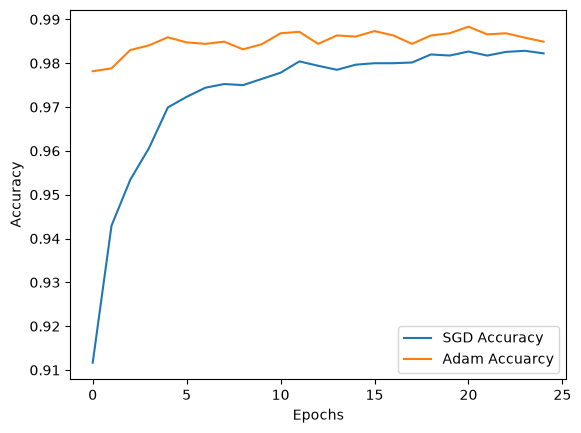

In [14]:
plt.plot(sgd_accuracy, label="SGD Accuracy")
plt.plot(adam_accuarcy, label="Adam Accuarcy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

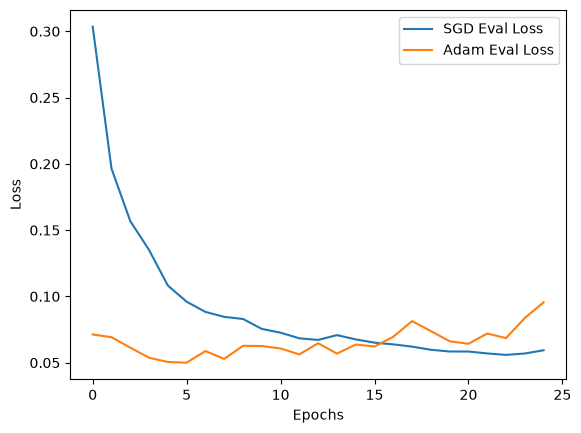

In [15]:
plt.plot(sgd_eval_loss, label="SGD Eval Loss")
plt.plot(adam_eval_loss, label="Adam Eval Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

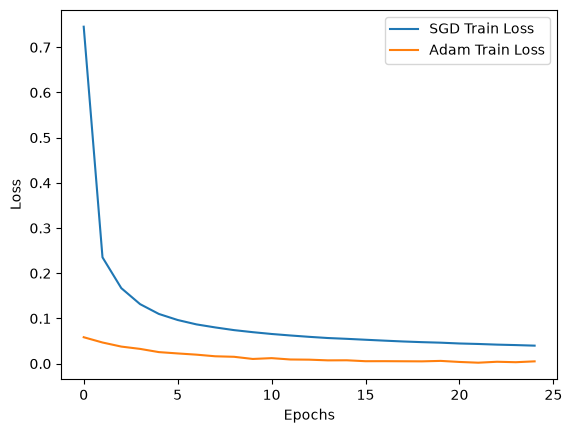

In [16]:
plt.plot(sgd_train_loss, label="SGD Train Loss")
plt.plot(adam_train_loss, label="Adam Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()